# Техничесткое задание для маркетингово исследования 2ГИС.

- Автор: Бышин М.И. (hh.ru/resume/3a27e4d7ff0ef40ab90039ed1f6f445a567078)

**Устанавливаем библиотеки:**

In [6]:
#!pip install psycopg2

In [7]:
# Импортируем библиотеки
import pandas as pd
import psycopg2

# Загружаем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

## Задание № 1
##### Сегментация пользователей мобильной игры по географии.
Требования:
- Напиши python-запрос в jupyter-ноутбуке, в котором с помощью библиотеки psycopg2 и SQL рассчитаешь количество уникальных пользователей по странам используя данные из таблицы mobile_game_raw.all_events из базы project.
- Результат выведи в виде столбчатой диаграммы используя свою любимую библиотеку для визуализации.
- (Параметры для работы: ‘country’, ‘user_id’)

### Знакомство с данными

In [8]:
# Данные для подключения
dbname = "project"
user = "student"
password = "b5af9527fa"
host = "sql.data-diving.ru"
port = "5432"

# Подключение к БД
try:
    conn = psycopg2.connect(
        dbname=dbname,
        user=user,
        password=password,
        host=host,
        port=port
    )
    print("Подключение к базе данных успешно!")

    # Создаем курсор
    cursor = conn.cursor()

    # Запрос к таблице
    query = "SELECT * FROM mobile_game_raw.all_events;" 
    cursor.execute(query)

    # Получаем данные
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]  # Получаем названия столбцов

    # Преобразуем в DataFrame
    df = pd.DataFrame(data, columns=columns)
    print(df)

except Exception as e: # на случай ошибки
    print(f"Ошибка подключения: {e}") 

finally:
    # Закрываем соединение
    if 'conn' in locals():
        conn.close()
        print("Соединение с базой данных закрыто.")

Подключение к базе данных успешно!
                event_time  user_id  country platform app_version  \
0      2023-02-28 13:23:03   529531      USA      ios       1.0.0   
1      2023-02-28 13:43:02   529377      USA  android       1.0.0   
2      2023-02-28 14:14:00   532496      USA      ios       1.0.0   
3      2023-02-28 14:16:21   536547      USA      ios       1.0.0   
4      2023-02-28 14:19:30   218698      USA      ios       1.0.0   
...                    ...      ...      ...      ...         ...   
302329 2023-12-15 20:47:22   478344  Germany      ios       1.3.0   
302330 2023-12-15 20:48:38   356412       UK      ios       1.3.0   
302331 2023-12-15 22:04:36   380448  Germany      ios       1.3.0   
302332 2023-12-15 23:46:35   497162    Japan  android       1.3.0   
302333 2023-12-16 00:39:06   599691    India      ios       1.3.0   

           event_name                                    user_properties  \
0       session_start  {'segments': {'gaming_skill': 3, 'pay

In [9]:
# Знакомство
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302334 entries, 0 to 302333
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   event_time        302334 non-null  datetime64[ns]
 1   user_id           302334 non-null  int64         
 2   country           302334 non-null  object        
 3   platform          302334 non-null  object        
 4   app_version       302334 non-null  object        
 5   event_name        302334 non-null  object        
 6   user_properties   302334 non-null  object        
 7   event_properties  22437 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 18.5+ MB


In [10]:
# Осмотр
df.head(302334)

,event_time,user_id,country,platform,app_version,event_name,user_properties,event_properties
0,2023-02-28 13:23:03,529531,USA,ios,1.0.0,session_start,"{'segments': {'gaming_skill': 3, 'payer_segmen...",None
1,2023-02-28 13:43:02,529377,USA,android,1.0.0,session_start,"{'segments': {'gaming_skill': 0, 'payer_segmen...",None
2,2023-02-28 14:14:00,532496,USA,ios,1.0.0,session_start,"{'segments': {'gaming_skill': 0, 'payer_segmen...",None
3,2023-02-28 14:16:21,536547,USA,ios,1.0.0,session_start,"{'segments': {'gaming_skill': 1, 'payer_segmen...",None
4,2023-02-28 14:19:30,218698,USA,ios,1.0.0,session_start,"{'segments': {'gaming_skill': 2, 'payer_segmen...",None
...,...,...,...,...,...,...,...,...
302329,2023-12-15 20:47:22,478344,Germany,ios,1.3.0,transaction,"{'segments': {'gaming_skill': 3, 'payer_segmen...","{'transaction': {'revenue': 5.99, 'quantity': ..."
302330,2023-12-15 20:48:38,356412,UK,ios,1.3.0,transaction,"{'segments': {'gaming_skill': 2, 'payer_segmen...","{'transaction': {'revenue': 5.99, 'quantity': ..."
302331,2023-12-15 22:04:36,380448,Germany,ios,1.3.0,transaction,"{'segments': {'gaming_skill': 0, 'payer_segmen...","{'transaction': {'revenue': 5.99, 'quantity': ..."
302332,2023-12-15 23:46:35,497162,Japan,android,1.3.0,transaction,"{'segments': {'gaming_skill': 2, 'payer_segmen...","{'transaction': {'revenue': 5.99, 'quantity': ..."


In [11]:
# Считаем количество уникальных user_id
df['user_id'].nunique()

31176

##### Не доконца понял каким образом необходимо решать задачу, поэтому предлагаю два варианта.

### Решение V1 при помощи psycopg2

In [12]:
# Данные для подключения
dbname = "project"
user = "student"
password = "b5af9527fa"
host = "sql.data-diving.ru"
port = "5432"

# Подключение к БД
try:
    conn = psycopg2.connect(
        dbname=dbname,
        user=user,
        password=password,
        host=host,
        port=port
    )
    print("Подключение к базе данных успешно!")

    # Создаем курсор
    cursor = conn.cursor()

    # SQL запрос к таблице 
    query = """
    SELECT country, COUNT(DISTINCT user_id) 
    FROM mobile_game_raw.all_events 
    GROUP BY country 
    ORDER BY COUNT(DISTINCT user_id) DESC;
    """
    cursor.execute(query)

    # Получаем данные
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]  # Получаем названия столбцов

    # Преобразуем в датафрейм
    DataFrame = pd.DataFrame(data, columns=columns)
    print(DataFrame)

except Exception as e: # на случай ошибки
    print(f"Ошибка подключения: {e}") 

finally:
    # Закрываем соединение
    if 'conn' in locals():
        conn.close()
        print("Соединение с базой данных закрыто.")

Подключение к базе данных успешно!
   country  count
0      USA  14473
1    India   4098
2  Germany   3336
3    Japan   2845
4   Brazil   2743
5       UK   2457
6    Italy   1224
Соединение с базой данных закрыто.


### Решение V2 python-pandas

In [13]:
# Группировка user_id по стране и сортировка
group_id_unique = df.groupby('country')['user_id'].nunique().sort_values(ascending=False)
print(group_id_unique)

country
USA        14473
India       4098
Germany     3336
Japan       2845
Brazil      2743
UK          2457
Italy       1224
Name: user_id, dtype: int64


### Визуализация

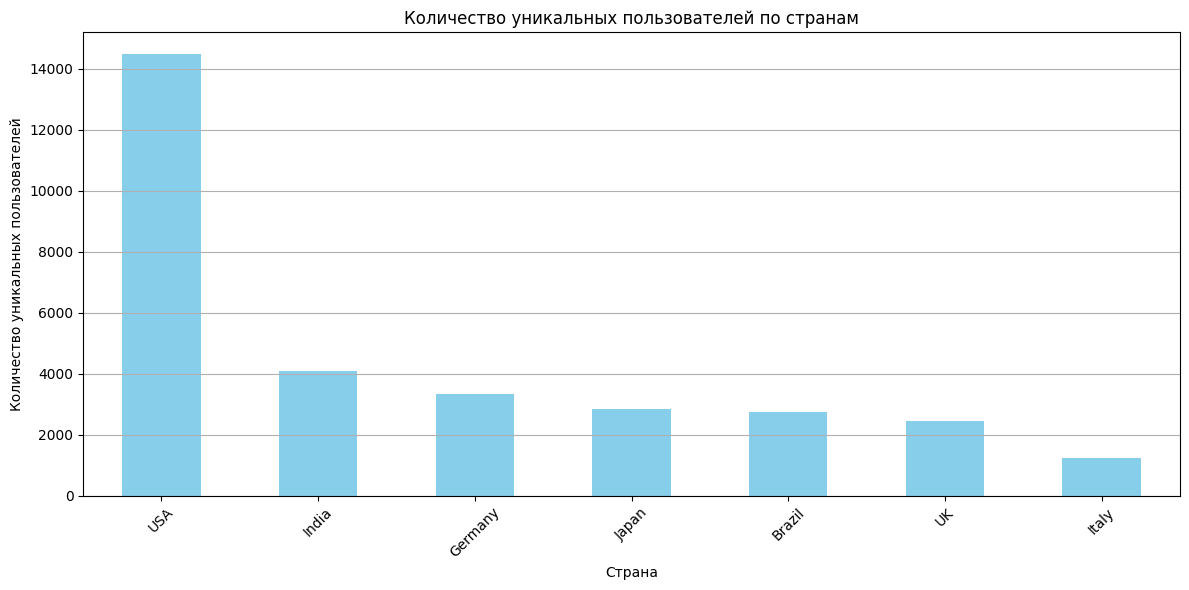

In [14]:
# Визуализация
plt.figure(figsize=(12, 6))
group_id_unique.plot(kind='bar', color='skyblue')  # Столбчатая диаграмма
plt.title('Количество уникальных пользователей по странам')
plt.xlabel('Страна') 
plt.ylabel('Количество уникальных пользователей') 
plt.xticks(rotation=45)  # Угол наклона по оси X 
plt.grid(axis='y')  # Добавление сетки по оси Y
plt.tight_layout()  # Автоматическая подгонка графика
plt.show()

## Задание № 2
##### Анализ выручки по странам и продуктам с помесячной детализацией.

- Построй тепловую карту выручки по связке “страна + продукт” по месяцам по данным из базы project из таблицы mobile_game_raw.all_events. 
- Цель - понять распределение выручки по странам и продуктам и выявить ключевые источники дохода продукта. 
- (Параметры для работы: ‘country’, 'transaction', 'revenue', 'product_name', 'year', 'month')

### Решение

Для решения данной задачи необходимо: `
- Сформировать новый датафрейм по полю `event_name' == transaction`. Таким образом получим 22437 строк.
- Оставить в датафрейме необходимые столбцы `event_time`, `country` и `event_properties`.
- Извлечь данные из столбца `event_properties`, которые находятся в формате списка, и сформировать из них столбцы `transaction`, `revenue`, `product_name` и тд.
- Из столбца `event_time` необходимо вытащить даты.
- Построить тепловую карту по готовому датафрейму.

##### Предобработка данных

In [16]:
# Фильтруем датафрейм по полю event_name == 'transaction'
filtered_df = df[df['event_name'] == 'transaction']

# Удаляем все столбцы, кроме event_time, country и event_properties
result_df = filtered_df[['event_time', 'country', 'event_properties']]

# Смотрим результат
result_df.head()

,event_time,country,event_properties
279897,2023-03-01 01:50:15,USA,"{'transaction': {'revenue': 5.99, 'quantity': ..."
279898,2023-03-01 01:55:35,Germany,"{'transaction': {'revenue': 5.99, 'quantity': ..."
279899,2023-03-01 02:18:56,USA,"{'transaction': {'revenue': 5.99, 'quantity': ..."
279900,2023-03-01 02:29:35,Germany,"{'transaction': {'revenue': 5.99, 'quantity': ..."
279901,2023-03-01 02:39:56,USA,"{'transaction': {'revenue': 5.99, 'quantity': ..."


In [17]:
# Функция для извлечения данных из словаря event_properties
def extract_properties(row):
    # Получаем словарь
    props = row['event_properties']
    
    # Если значение является строкой
    if isinstance(props, str):
        props = eval(props)  # Быстрое преобразование строки в словарь
    
    # Получаем вложенный словарь transaction
    transaction = props['transaction']
    
    # Возвращаем series с извлеченными значениями
    return pd.Series([
        transaction['revenue'],        # Извлекаем revenue (гарантировано существует)
        transaction['quantity'],       # Извлекаем quantity (гарантировано существует)
        transaction['product_id'],     # Извлекаем product_id (гарантировано существует)
        transaction['product_name'],   # Извлекаем product_name (гарантировано существует)
        transaction['transaction_id']  # Извлекаем transaction_id (гарантировано существует)
    ])

# Применяем функцию к каждой строке и создаем новые столбцы
# Используем pd.concat для большей производительности
new_columns = result_df.apply(extract_properties, axis=1)
result_df = pd.concat([
    result_df.drop('event_properties', axis=1),
    new_columns
], axis=1)

# Переименовываем новые столбцы
result_df.columns = list(result_df.columns[:-5]) + ['revenue', 'quantity', 'product_id', 'product_name', 'transaction_id']

# Преобразуем типы(опционально)
result_df['revenue'] = result_df['revenue'].astype(float)
result_df['quantity'] = result_df['quantity'].astype(int)

# Смотрим результат
print(result_df.head())

                event_time  country  revenue  quantity  product_id  \
279897 2023-03-01 01:50:15      USA     5.99         1           2   
279898 2023-03-01 01:55:35  Germany     5.99         1           2   
279899 2023-03-01 02:18:56      USA     5.99         1           2   
279900 2023-03-01 02:29:35  Germany     5.99         1           2   
279901 2023-03-01 02:39:56      USA     5.99         1           2   

         product_name  transaction_id  
279897  hard_currency             546  
279898  hard_currency             109  
279899  hard_currency             547  
279900  hard_currency             110  
279901  hard_currency             549  


In [18]:
result_df.nunique()

event_time        22109
country               7
revenue               3
quantity              1
product_id            3
product_name          3
transaction_id    22437
dtype: int64

In [19]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22437 entries, 279897 to 302333
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   event_time      22437 non-null  datetime64[ns]
 1   country         22437 non-null  object        
 2   revenue         22437 non-null  float64       
 3   quantity        22437 non-null  int64         
 4   product_id      22437 non-null  int64         
 5   product_name    22437 non-null  object        
 6   transaction_id  22437 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 1.4+ MB


In [21]:
# Создаем копию датафрейма и преобразуем дату в месяц
df = result_df.copy()
df['month'] = df['event_time'].dt.to_period('M').astype(str)

##### Тепловая карта

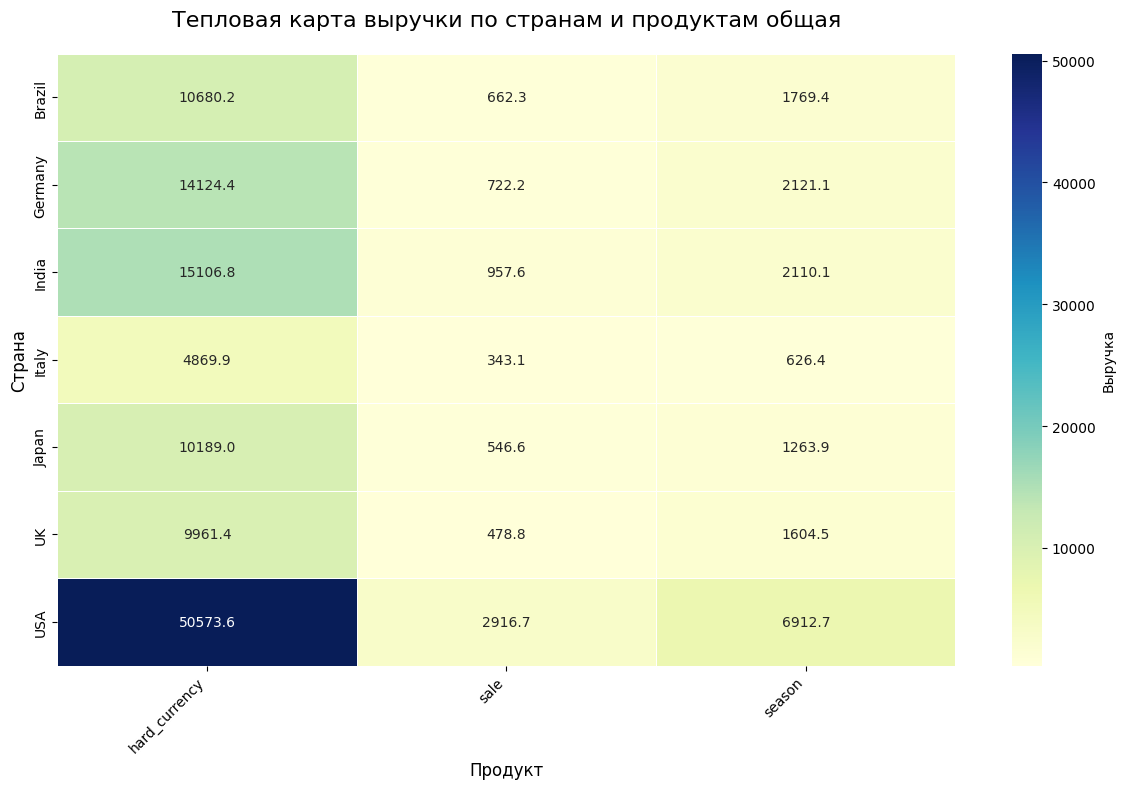

In [23]:
# Группируем данные по стране и продукту, суммируя выручку
heatmap_data = df.groupby(['country', 'product_name'])['revenue'].sum().unstack()

# Создаем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Выручка'}
)

plt.title('Тепловая карта выручки по странам и продуктам общая', pad=20, fontsize=16)
plt.xlabel('Продукт', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

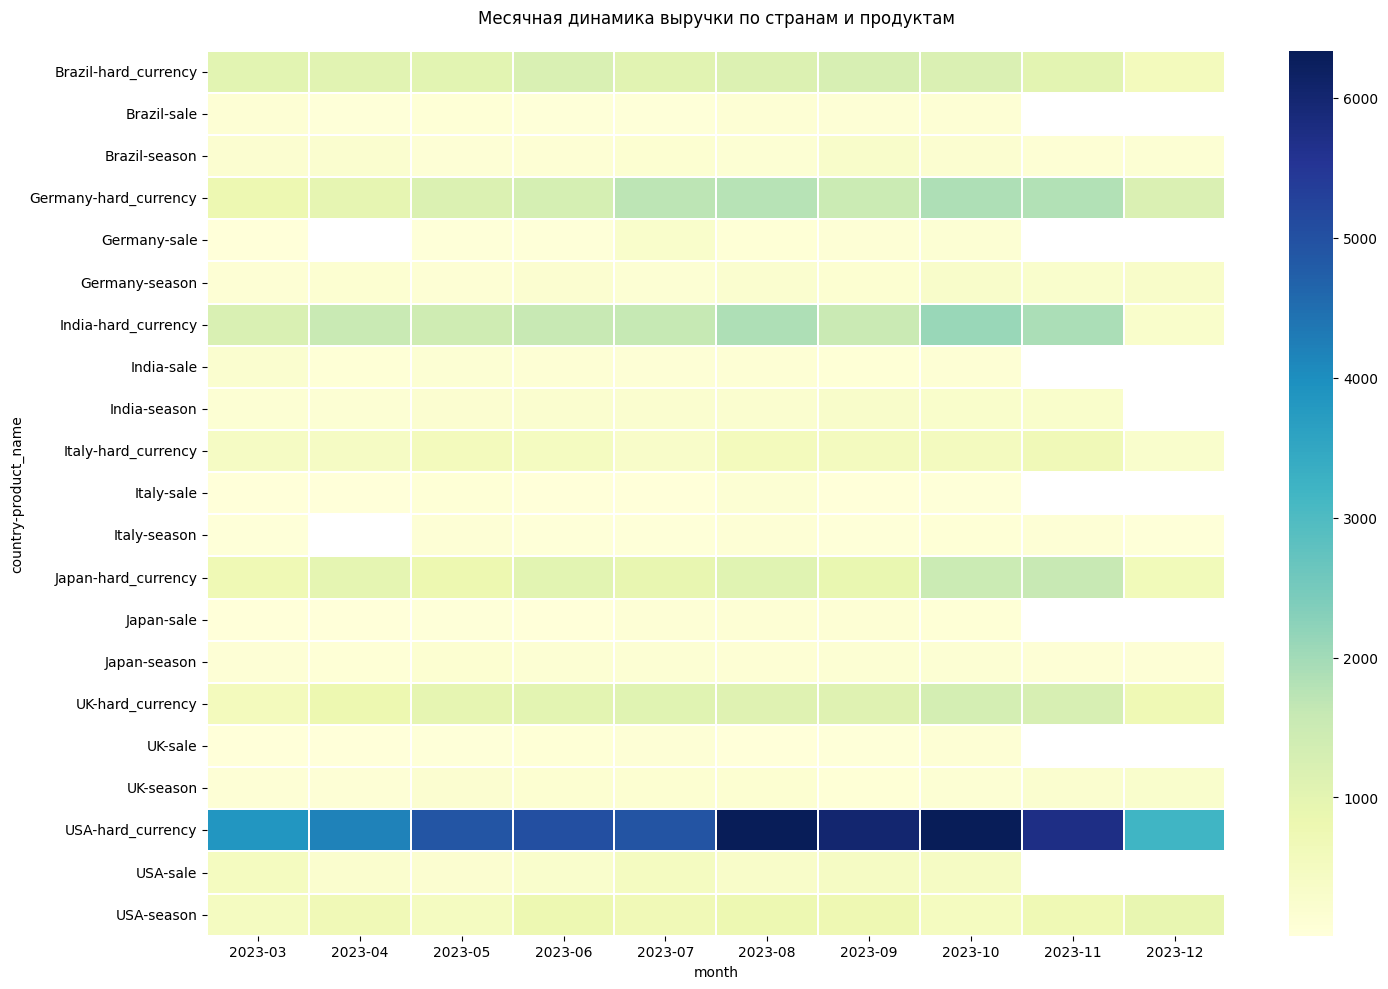

In [24]:
# Группировка с учетом месяцев
heatmap_data_monthly = df.groupby(['country', 'product_name', 'month'])['revenue'].sum().unstack()

# Визуализация данных
plt.figure(figsize=(15, 10))
sns.heatmap(
    heatmap_data_monthly,
    cmap='YlGnBu',
    annot=False,  # Убрал аннотации для читаемости
    linewidths=0.1
)
plt.title('Месячная динамика выручки по странам и продуктам', pad=20)
plt.tight_layout()
plt.show()